# Module: Plotting

One of the main usecases of `SegTraQ` is to compare different segmentation methods.
To facilitate this task, you can make use of the plotting module (`pl`).
In order to use it, you need to prepare your data in the form of a dictionary
that maps the method name to the corresponding `SegTraQ` object.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/YSvZTt8AArh4c5a).

## Data Preparation

First, we need to get the data into the right format.
This closely follows the [Xenium Focus](10x_xenium_focus.ipynb).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

segtraq.settings.n_jobs = -1  # Use all available CPU cores

/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# === READING SPATIALDATA OBJECTS ===
sdata_xenium_ws = sd.read_zarr("../../data/xenium_5K_data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/xenium_5K_data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/xenium_5K_data/proseg2.zarr")
sdata_segger_ws = sd.read_zarr("../../data/xenium_5K_data/segger.zarr")

# === CROPPING ===
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h


def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)
sdata_segger = crop(sdata_segger_ws)

# === CREATING SEGTRAQ OBJECTS ===
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="cell_centroid_x",
    tables_centroid_y_key="cell_centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_cell_id_key="assignment",
    points_background_id=2**32 - 1,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

st_segger = segtraq.SegTraQ(
    sdata_segger, images_key="image", tables_centroid_x_key="cell_centroid_x", tables_centroid_y_key="cell_centroid_y"
)

# === PUTTING EVERYTHING INTO A DICTIONARY ===
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg, "segger": st_segger}

no parent found for <ome_zarr.reader.Label object at 0x7ffee3c66cf0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffee3cb2350>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffee82f5e50>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffee3c76650>: None


/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:2136: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:180: UserWarning: Filtering control probes matching prefixes ('NegControlProbe_', 'antisense_', 'NegControlCodeword', 'BLANK_', 'Blank-', 'NegPrb', 'DeprecatedCodeword_', 'UnassignedCodeword_', 'Intergenic_Region_') and transcripts with qv < 20 from transcript points in-place; control probes are also removed from the expression table if present. Configure `min_qv`, `control_prefixes`, and `inplace` via `filter_kwargs`.
  sdata_new = _filter_control_and_low_quality_transcripts(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:180: RuntimeWarning: Gene sets differ between assigned transcript points and the expression table. 0 genes occur only in points (e.g. []), and 455 occur only

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:180: UserWarning: Filtering control probes matching prefixes ('NegControlProbe_', 'antisense_', 'NegControlCodeword', 'BLANK_', 'Blank-', 'NegPrb', 'DeprecatedCodeword_', 'UnassignedCodeword_', 'Intergenic_Region_') and transcripts with qv < 20 from transcript points in-place; control probes are also removed from the expression table if present. Configure `min_qv`, `control_prefixes`, and `inplace` via `filter_kwargs`.
  sdata_new = _filter_control_and_low_quality_transcripts(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:180: RuntimeWarning: Gene sets differ between assigned transcript points and the expression table. 0 genes occur only in points (e.g. []), and 438 occur only in the table (e.g. ['TM6SF2', 'HPV16-E6', 'HTR1A', 'C9', 'ALX1']). Genes only occuring in the table can be introduced by cropping (`SpatialData`), but differences may also be due to the filtering used to generate the transcript data and expression 

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:180: RuntimeWarning: Gene sets differ between assigned transcript points and the expression table. 0 genes occur only in points (e.g. []), and 623 occur only in the table (e.g. ['UTS2', 'TM6SF2', 'HTR1A', 'C8G', 'C9']). Genes only occuring in the table can be introduced by cropping (`SpatialData`), but differences may also be due to the filtering used to generate the transcript data and expression matrix. Please check that `filter_kwargs`, particularly `min_qv` and `control_prefixes`, are consistent with the filtering used to generate the expression table.
  sdata_new = _filter_control_and_low_quality_transcripts(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:180: RuntimeWarning: Cell IDs differ between assigned transcript points and the expression table. 1 cells occur only in points (e.g. ['iponnlbk-1']), and 0 occur only in the table (e.g. []). Cells only occuring in the table can reflect zero-count cells, but differen

## Run desired metrics
Now, we can run all of the metrics we want on this dataset.
For now, we simply run a label transfer and run some `scanpy` functions to compute the UMAP coordinates.

In [4]:
# Load scRNA-seq data
adata_ref = ad.read_h5ad("../../data/xenium_5K_data/BC_scRNAseq_Janesick.h5ad")

# Transfer labels
for _method, st in st_dict.items():
    st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_raw_counts_layer="raw", inplace=True)

# Plots for individual samples

The `pl` module provides methods to plot different things: on one hand,
it can be used to visualize certain characteristics of a sample,
and on the other, it can be used to compare between different samples or segmentation methods.
Let's start by looking at some sample-specific plots. Specifically,
we can look at the distribution of transcripts and different segmentation features across
the x and y coordinate. For some technologies (such as CosMx),
this can help to detect stitching artefacts.

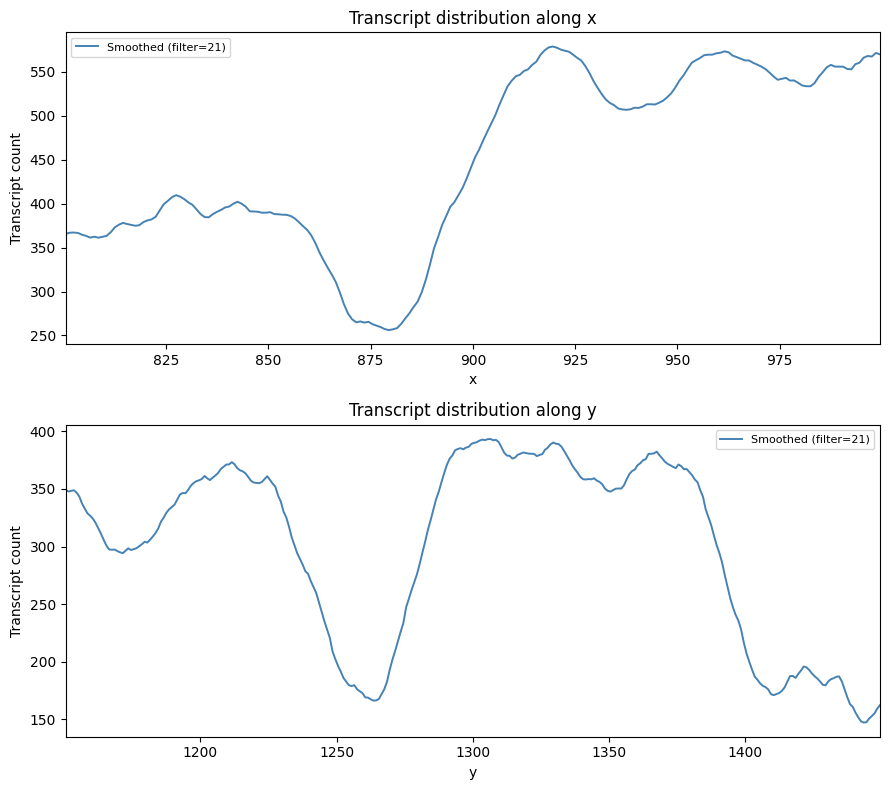

In [5]:
# transcript distribution across the x and y axis of the image
# the filter size (default: 21) can be used to get an idea for broader trends
_ = st_xenium.pl.transcript_distribution_across_space(filter_size=21)

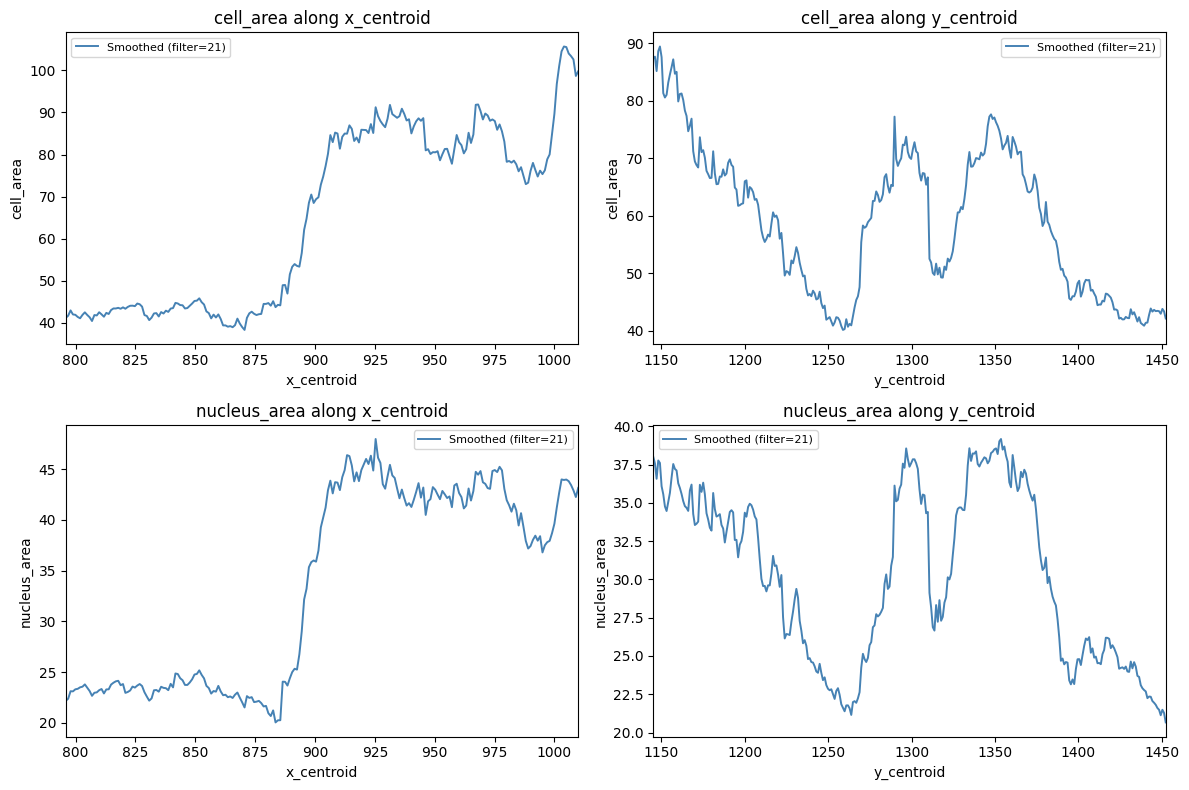

In [6]:
# features of the segmentation across the axes
_ = st_xenium.pl.feature_distribution_across_space(features=["cell_area", "nucleus_area"], filter_size=21)

We can see two things here: for the Xenium segmentation,
the right part of the image contains more transcripts.
Its cells are also larger. We can use `spatialdata_plot` to have a look at the actual data.

/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(


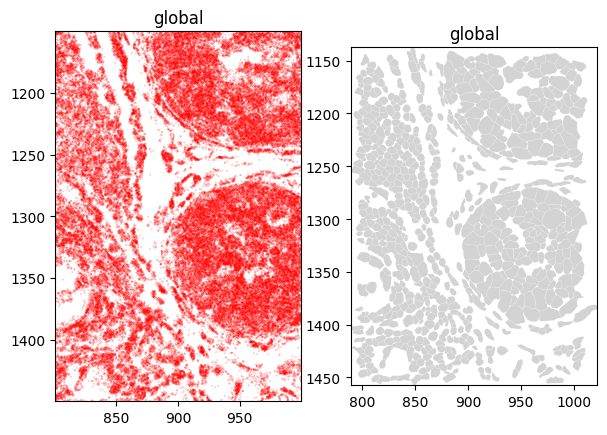

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(7, 7), dpi=100)
st_xenium.sdata.pl.render_points("transcripts", size=0.01, color="red", method="matplotlib").pl.show(ax=ax[0])
st_xenium.sdata.pl.render_shapes("cell_boundaries").pl.show(ax=ax[1])

Here, this is actually due to the structure of the tissue
(large tumor cells are on the right side of the image).
When applying these methods on larger tissues, they can also help to detect technical artefacts.

# Comparing between segmentation methods

We can also use the `pl` module to compare between different segmentation methods.
All we need to do is pass our dictionary of `SegTraQ` objects.

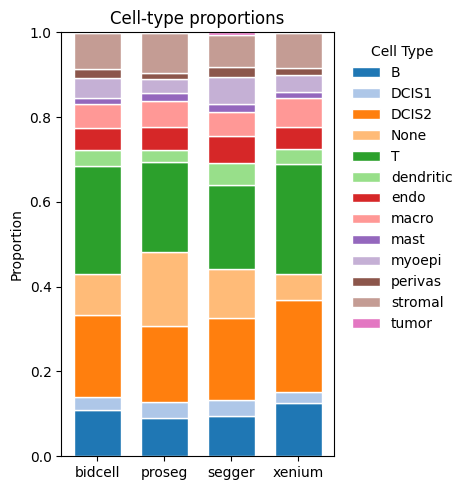

In [8]:
_ = segtraq.pl.celltype_proportions(st_dict, celltype_col="transferred_cell_type")

Before we can plot the UMAP, we need to actually compute it.

In [9]:
for _, st in st_dict.items():
    # extracting the anndata object from the spatialdata object and performing appropriate normalization
    adata = st.sdata.tables["table"]
    adata.layers["raw"] = adata.X.copy()
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

/tmp/ipykernel_272351/2922093549.py:5: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, inplace=True)


/tmp/ipykernel_272351/2922093549.py:5: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, inplace=True)


/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


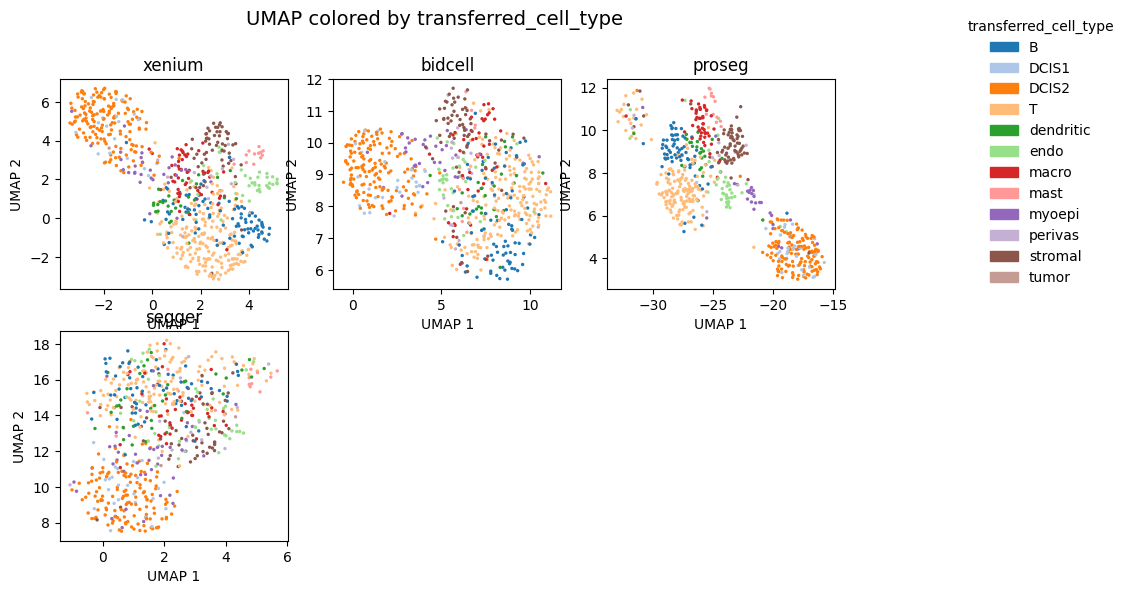

In [10]:
_ = segtraq.pl.umap(st_dict, color="transferred_cell_type", legend=True, figsize=(10, 6))

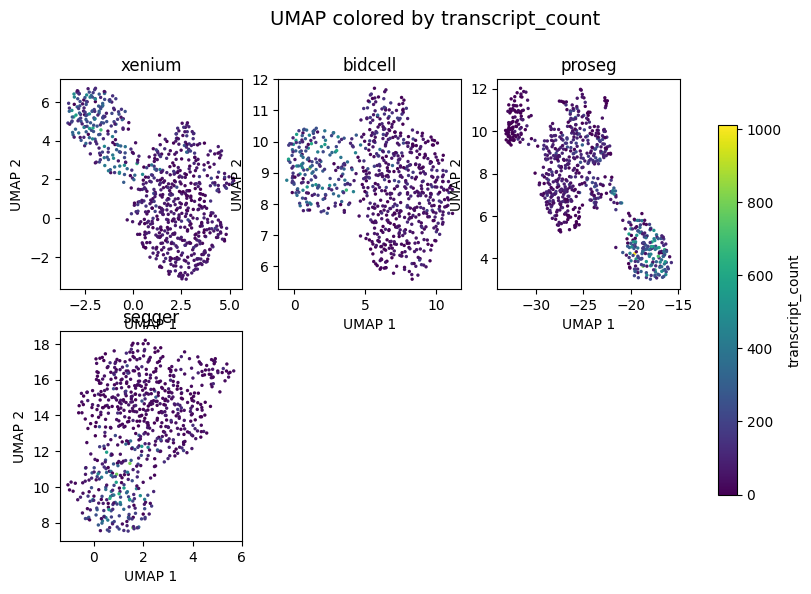

In [11]:
_ = segtraq.pl.umap(st_dict, color="transcript_count", legend=True, figsize=(10, 6))

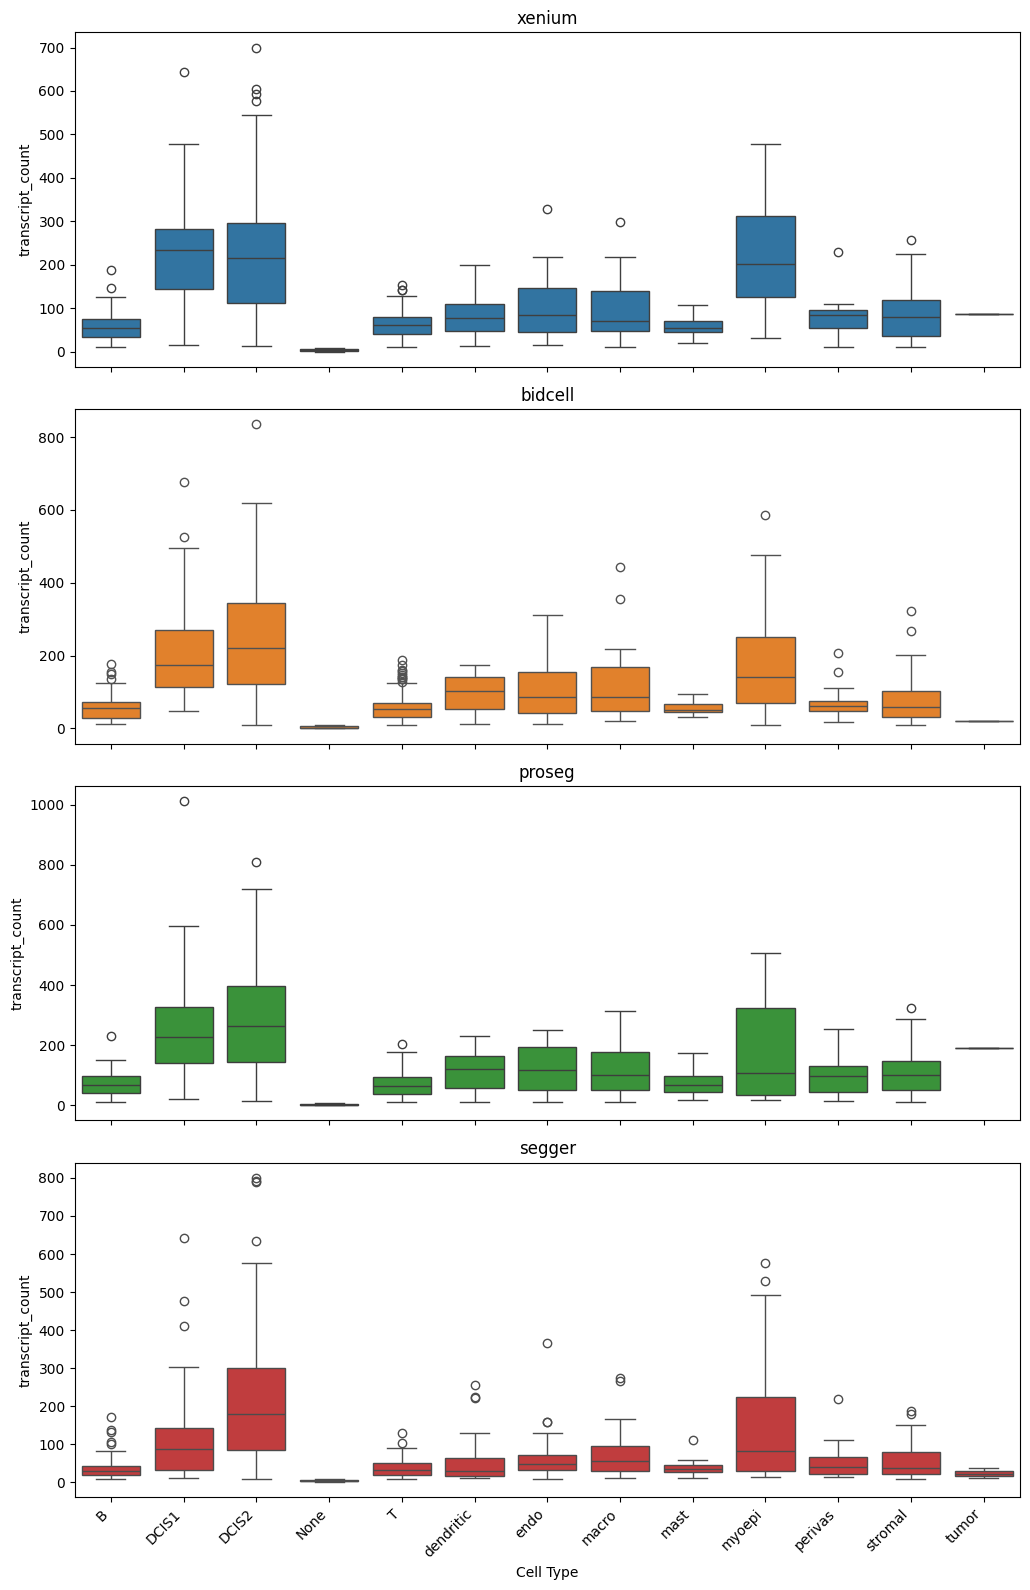

In [12]:
_ = segtraq.pl.boxplot(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")

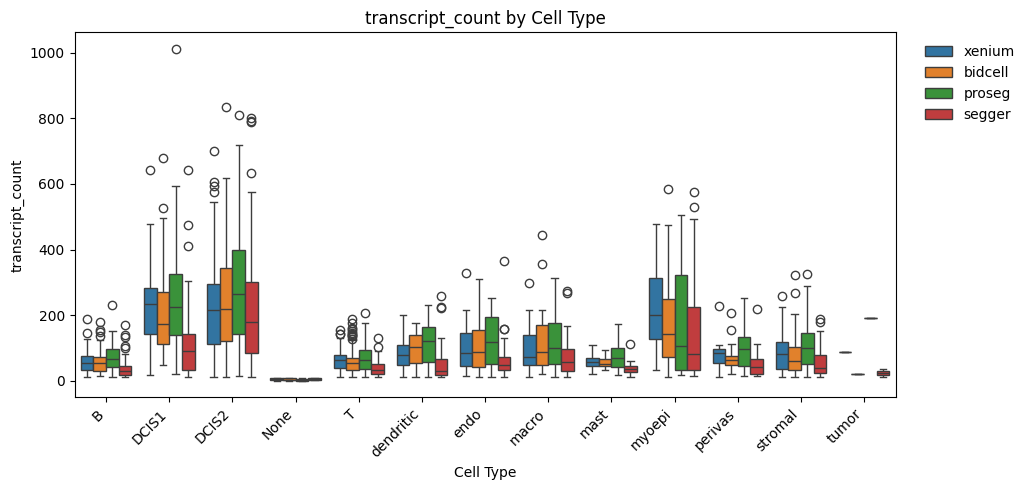

In [13]:
_ = segtraq.pl.boxplot_combined(st_dict, celltype_col="transferred_cell_type", value_key="transcript_count")

## Session Info

In [14]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.8.0
0.4.0
